# 07 - Physics Diagnostics & Robustness (Slim)

This notebook keeps only the core checks needed for reporting:

1. Stage progression (`stageBase` -> `stageCorrected` -> `stageFinal`)
2. Physics diagnostics aligned with the diagnostics module
3. Seed robustness across report seeds

Artifacts are loaded from the first available root in:
- `results/ml/final/`
- `outputs/ml/final_comparison/`

In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skin_diffusion.notebook_helpers import setup_repo_root

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

required_seeds = [42, 123, 7]
primary_seed = 42
target_names = ['P', 'J_ss', 'J_peak', 't_peak', 'M_delivered_24h']

run_root_candidates = [
    Path('results/ml/final'),
    Path('outputs/ml/final_comparison'),
]
run_root = next((p for p in run_root_candidates if p.exists()), None)
if run_root is None:
    raise FileNotFoundError(f'None of run roots exist: {run_root_candidates}')

corr_run_dirs = {seed: run_root / f'corrective_ridge_seed{seed}' for seed in required_seeds}
missing = [seed for seed, d in corr_run_dirs.items() if not d.exists()]
if missing:
    raise FileNotFoundError(
        f'Missing corrective result directories under {run_root}: {missing}'
    )

seed_order = required_seeds

bb_diag = json.load(open(run_root / 'blackbox_ridge' / 'diagnostics/physics/physics_diag_test_summary.json'))
corr_diag = json.load(open(corr_run_dirs[primary_seed] / 'diagnostics/physics/physics_diag_test_summary.json'))

corr_seeds = {}
for seed in seed_order:
    corr_seeds[seed] = json.load(open(corr_run_dirs[seed] / 'summary.json'))

corr_metrics = json.load(open(corr_run_dirs[primary_seed] / 'metrics_test.json'))

print('Core artifacts loaded.')
print(f'Run root: {run_root}')
print(f'Primary seed: {primary_seed}; report seeds: {seed_order}')

Core artifacts loaded.
Run root: results/ml/final
Primary seed: 42; report seeds: [42, 123, 7]


## 1 - Stage progression

The prediction pipeline has three stages:
- `stageBase`: PCA-Ridge backbone
- `stageCorrected`: additive corrective output
- `stageFinal`: validation-selected no-harm blend

This panel shows how curve metrics move across stages on the test set.

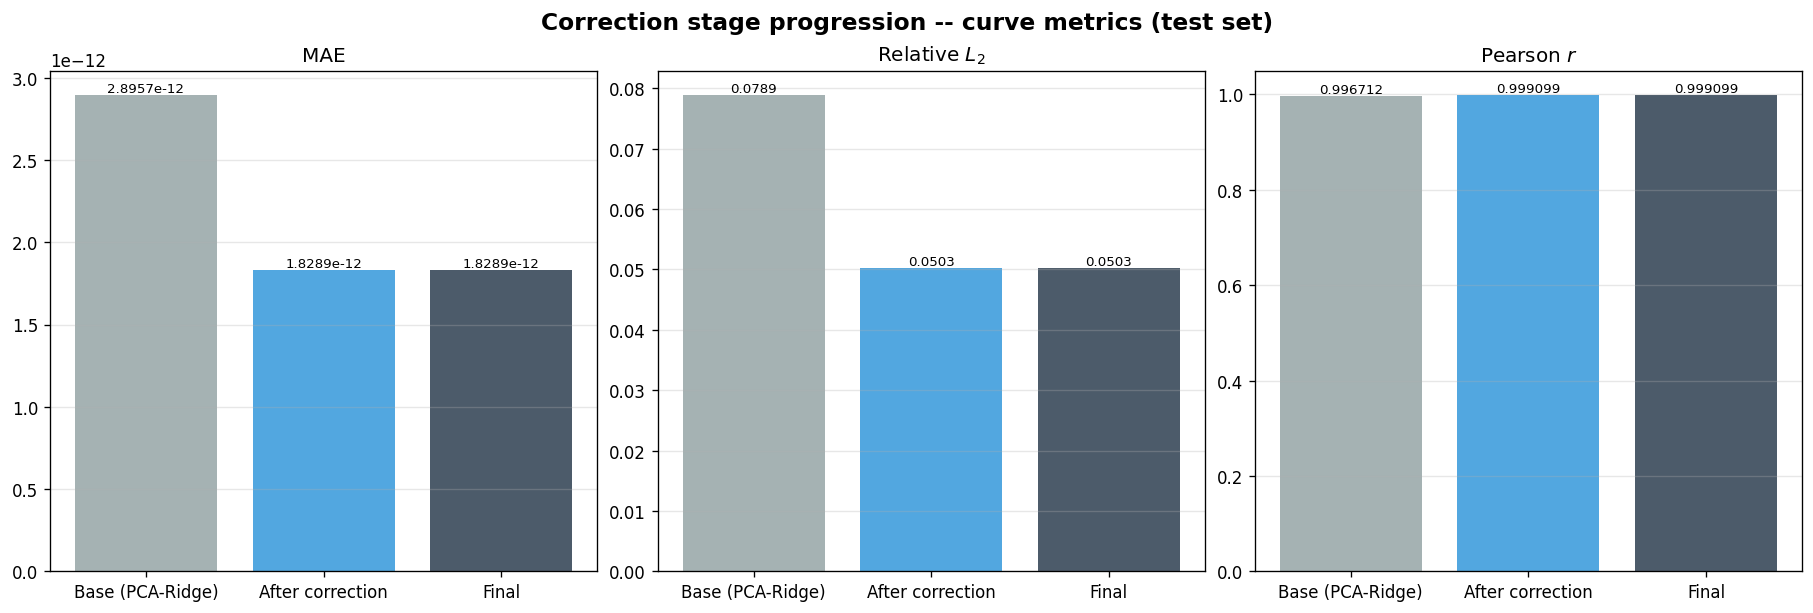

Relative L_2 improvement: 0.0789 -> 0.0503 (36.2% reduction)


In [16]:
stages = ['stageBase', 'stageCorrected', 'stageFinal']
stage_labels = ['Base (PCA-Ridge)', 'After correction', 'Final']
stage_colours = ['#95a5a6', '#3498db', '#2c3e50']

curve_keys = ['mae', 'relative_l2', 'pearson_r']
curve_labels = ['MAE', 'Relative $L_2$', 'Pearson $r$']

missing = [s for s in stages if s not in corr_metrics]
if missing:
    raise KeyError(f'Missing expected stage keys in metrics_test.json: {missing}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
fig.suptitle('Correction stage progression -- curve metrics (test set)', fontsize=14, fontweight='bold')

for ax, key, ylabel in zip(axes, curve_keys, curve_labels):
    vals = [corr_metrics[s]['curve'][key] for s in stages]
    bars = ax.bar(stage_labels, vals, color=stage_colours, alpha=0.85)
    ax.set_title(ylabel)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        if key == 'pearson_r':
            text = f'{val:.6f}'
        else:
            text = f'{val:.4e}' if val < 0.001 else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                text, ha='center', va='bottom', fontsize=8)

plt.show()

# Improvement ratio
base_l2 = corr_metrics['stageBase']['curve']['relative_l2']
final_l2 = corr_metrics['stageFinal']['curve']['relative_l2']
print(f'Relative L_2 improvement: {base_l2:.4f} -> {final_l2:.4f} '
      f'({(1 - final_l2/base_l2)*100:.1f}% reduction)')


**Breakdown.**

- Relative $L_2$ is the main stage-level comparison metric.
- MAE and Pearson $r$ are shown as supporting context.
- StageFinal matching stageCorrected indicates blend selected full correction for this run.

## 2 - Physics diagnostics

These diagnostics follow the same metric family used in `ml_physics_diagnostics.py` and worst-case reports.

Black-box stage keys: ['bc_bottom_flux_rel_rmse', 'bc_bottom_flux_rmse', 'curve_mae', 'curve_relative_l2', 'ic_flux_abs_error', 'negative_flux_fraction', 'pde_mass_balance_rel_rmse', 'pde_mass_balance_rmse']
Corrective stage keys:  ['bc_bottom_flux_rel_rmse', 'bc_bottom_flux_rmse', 'curve_mae', 'curve_relative_l2', 'ic_flux_abs_error', 'negative_flux_fraction', 'pde_mass_balance_rel_rmse', 'pde_mass_balance_rmse', 'pde_stageBase_flux_rel_rmse', 'pde_stageBase_flux_rmse']


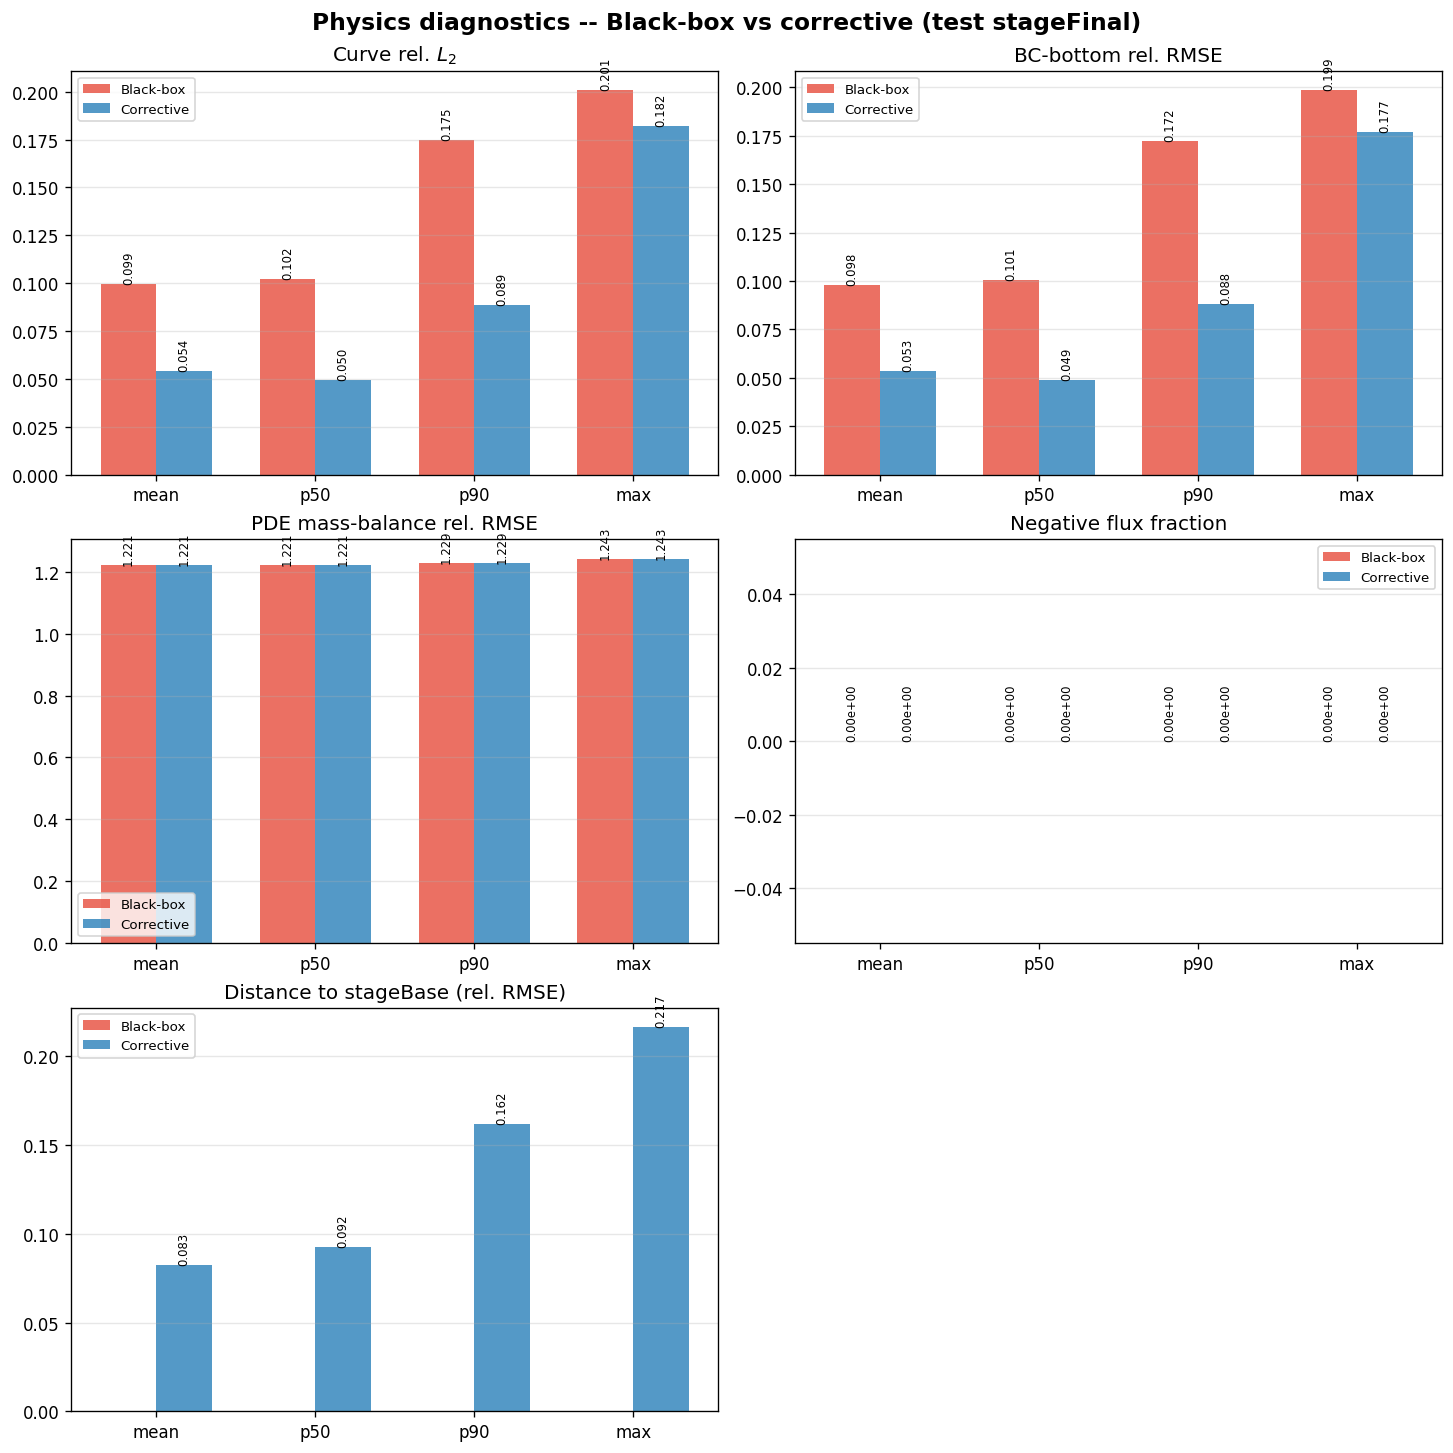


Compact summary (mean and p90):
metric                                    bb_mean    corr_mean       bb_p90     corr_p90
----------------------------------------------------------------------------------------
Curve rel. $L_2$                        0.0994155    0.0541619     0.174553    0.0887331
BC-bottom rel. RMSE                     0.0977303    0.0533478      0.17215    0.0879661
PDE mass-balance rel. RMSE                1.22137      1.22137      1.22855      1.22855
Negative flux fraction                          0            0            0            0
Distance to stageBase (rel. RMSE)             nan    0.0825395          nan     0.161634


In [17]:
# Robust stage extraction (handles direct and nested summary formats)
def extract_stage_block(diag_obj, stage_name='stageFinal'):
    if not isinstance(diag_obj, dict):
        return {}

    stages = diag_obj.get('stages', None)
    if isinstance(stages, dict) and stage_name in stages:
        return stages[stage_name]

    stage_flat = diag_obj.get(stage_name, None)
    if isinstance(stage_flat, dict):
        return stage_flat

    pd = diag_obj.get('physics_diagnostics', None)
    if isinstance(pd, dict):
        ts = pd.get('test_summary', None)
        if isinstance(ts, dict):
            st = ts.get('stages', None)
            if isinstance(st, dict) and stage_name in st:
                return st[stage_name]

    ts = diag_obj.get('test_summary', None)
    if isinstance(ts, dict):
        st = ts.get('stages', None)
        if isinstance(st, dict) and stage_name in st:
            return st[stage_name]

    return {}


def extract_stat_values(stage_block, metric_key, stat_names):
    metric = stage_block.get(metric_key, {})
    if isinstance(metric, dict):
        vals = []
        for s in stat_names:
            v = metric.get(s, np.nan)
            try:
                vals.append(float(v))
            except Exception:
                vals.append(np.nan)
        return np.array(vals, dtype=float)

    try:
        v = float(metric)
        return np.array([v] * len(stat_names), dtype=float)
    except Exception:
        return np.full(len(stat_names), np.nan, dtype=float)


# Keep the metric set aligned with ml_physics_diagnostics + worst-case reporting
metric_specs = [
    ('curve_relative_l2', 'Curve rel. $L_2$'),
    ('bc_bottom_flux_rel_rmse', 'BC-bottom rel. RMSE'),
    ('pde_mass_balance_rel_rmse', 'PDE mass-balance rel. RMSE'),
    ('negative_flux_fraction', 'Negative flux fraction'),
]

bb_stage = extract_stage_block(bb_diag, 'stageFinal')
corr_stage = extract_stage_block(corr_diag, 'stageFinal')

if ('pde_stageBase_flux_rel_rmse' in bb_stage) or ('pde_stageBase_flux_rel_rmse' in corr_stage):
    metric_specs.append(('pde_stageBase_flux_rel_rmse', 'Distance to stageBase (rel. RMSE)'))

print('Black-box stage keys:', sorted(bb_stage.keys()))
print('Corrective stage keys: ', sorted(corr_stage.keys()))

stat_names = ['mean', 'p50', 'p90', 'max']
x = np.arange(len(stat_names))
width = 0.35

n_panels = len(metric_specs)
ncols = 2
nrows = int(np.ceil(n_panels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows), constrained_layout=True)
axes_flat = np.array(axes).reshape(-1)
fig.suptitle('Physics diagnostics -- Black-box vs corrective (test stageFinal)', fontsize=14, fontweight='bold')

summary_rows = []

for ax, (metric_key, title) in zip(axes_flat, metric_specs):
    bb_vals = extract_stat_values(bb_stage, metric_key, stat_names)
    corr_vals = extract_stat_values(corr_stage, metric_key, stat_names)

    valid_mask = np.isfinite(bb_vals) | np.isfinite(corr_vals)
    if not np.any(valid_mask):
        ax.text(0.5, 0.5, 'No data found', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.set_xticks(x)
        ax.set_xticklabels(stat_names)
        ax.grid(axis='y', alpha=0.3)
        summary_rows.append((title, np.nan, np.nan, np.nan, np.nan))
        continue

    bb_plot = np.where(np.isfinite(bb_vals), bb_vals, 0.0)
    corr_plot = np.where(np.isfinite(corr_vals), corr_vals, 0.0)

    bars_bb = ax.bar(x - width/2, bb_plot, width, label='Black-box', color='#e74c3c', alpha=0.8)
    bars_corr = ax.bar(x + width/2, corr_plot, width, label='Corrective', color='#2980b9', alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(stat_names)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

    for bars, vals in [(bars_bb, bb_vals), (bars_corr, corr_vals)]:
        for bar, v in zip(bars, vals):
            if np.isfinite(v):
                txt = f'{v:.2e}' if abs(v) < 1e-2 else f'{v:.3f}'
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    txt,
                    ha='center',
                    va='bottom',
                    fontsize=7,
                    rotation=90,
                )

    bb_mean = bb_vals[0] if np.isfinite(bb_vals[0]) else np.nan
    corr_mean = corr_vals[0] if np.isfinite(corr_vals[0]) else np.nan
    bb_p90 = bb_vals[2] if np.isfinite(bb_vals[2]) else np.nan
    corr_p90 = corr_vals[2] if np.isfinite(corr_vals[2]) else np.nan
    summary_rows.append((title, bb_mean, corr_mean, bb_p90, corr_p90))

for ax in axes_flat[:n_panels]:
    ax.legend(fontsize=8)
for ax in axes_flat[n_panels:]:
    ax.axis('off')

plt.show()

print('\nCompact summary (mean and p90):')
print(f"{'metric':<36} {'bb_mean':>12} {'corr_mean':>12} {'bb_p90':>12} {'corr_p90':>12}")
print('-' * 88)
for title, bb_mean, corr_mean, bb_p90, corr_p90 in summary_rows:
    print(f"{title:<36} {bb_mean:12.6g} {corr_mean:12.6g} {bb_p90:12.6g} {corr_p90:12.6g}")


**Breakdown.**

- Primary checks: curve rel-$L_2$, BC-bottom rel-RMSE, PDE mass-balance rel-RMSE, and negative-flux fraction.
- `pde_stageBase_flux_rel_rmse` appears only for corrective and quantifies movement away from base.
- Interpret differences using mean/p90 first, then max as a worst-case indicator.

## 3 - Multi-seed robustness

Seed-to-seed spread is summarised using scalar RMSE and coefficient of variation (CV).

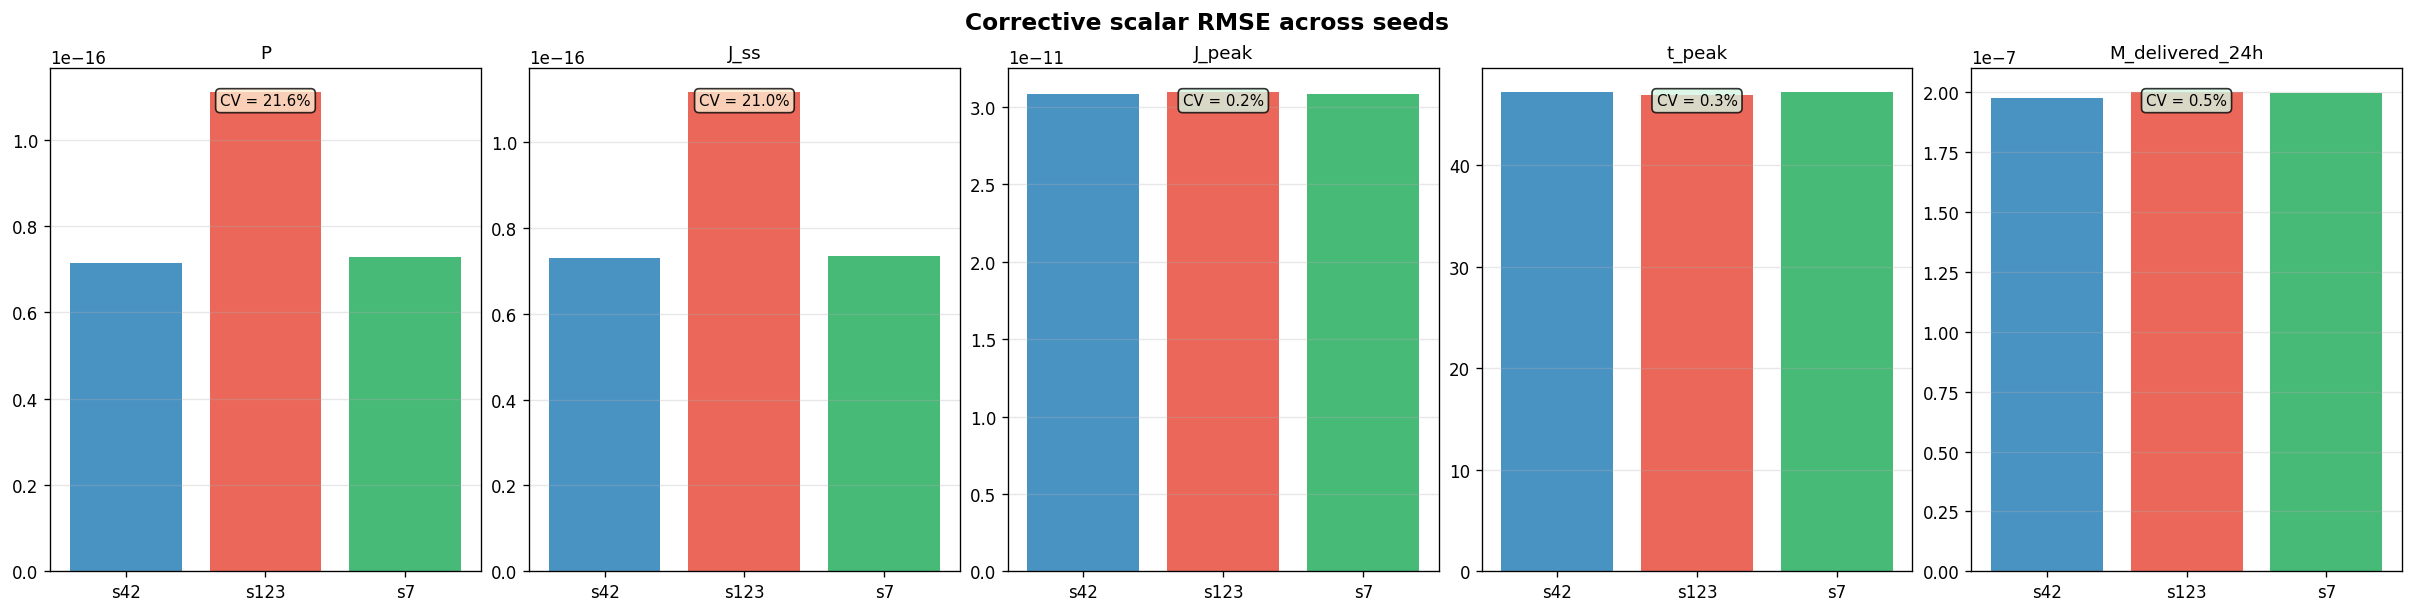


Runtime (seconds):
  seed 42: 105.1 s
  seed 123: 95.4 s
  seed 7: 107.0 s


In [18]:
seed_colours_local = {seed: colour for seed, colour in zip(seed_order, ['#2980b9', '#e74c3c', '#27ae60', '#8e44ad', '#f39c12'])}

fig, axes = plt.subplots(1, len(target_names), figsize=(20, 5), constrained_layout=True)
fig.suptitle('Corrective scalar RMSE across seeds', fontsize=14, fontweight='bold')

for ax, tname in zip(axes, target_names):
    vals = {s: corr_seeds[s]['test_scalar_rmse'][tname] for s in seed_order}
    bars = ax.bar([f's{s}' for s in vals.keys()], list(vals.values()),
                  color=[seed_colours_local[s] for s in vals.keys()], alpha=0.85)
    ax.set_title(tname, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    # Annotate CV
    arr = np.array(list(vals.values()))
    cv = np.std(arr) / np.mean(arr) * 100
    ax.text(0.5, 0.95, f'CV = {cv:.1f}%', transform=ax.transAxes,
            ha='center', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#d5f5e3' if cv < 10 else '#fdebd0',
                      alpha=0.8))

plt.show()

# Runtime comparison
print('\nRuntime (seconds):')
for seed in seed_order:
    rt = corr_seeds[seed].get('runtime_seconds', 0)
    print(f'  seed {seed}: {rt:.1f} s')


**Breakdown.**

- Lower CV means better seed stability.
- Runtime is printed only as a reproducibility sanity check.